In [96]:
!pip install numpy
!pip install pandas
!pip install matplotlib
!pip install seaborn
!pip install scikit-learn



[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [97]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score


In [98]:
path="C:\\Users\\CANSU\\Desktop\\ML\\NASA TURBOFAN DATASET\\train_FD001.txt"
df=pd.read_csv(path,sep=" ")

In [99]:
df.head()


,1,1.1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,8138.62,8.4195,0.03,392,2388,100.00,39.06,23.4190,Unnamed: 26,Unnamed: 27
0,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,NaN,NaN
1,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,NaN,NaN
2,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,NaN,NaN
3,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,NaN,NaN
4,1,6,-0.0043,-0.0001,100.0,518.67,642.10,1584.47,1398.37,14.62,...,8132.85,8.4108,0.03,391,2388,100.0,38.98,23.3669,NaN,NaN


In [100]:
df.shape

(20630, 28)

In [101]:
df.columns

Index(['1', '1.1', '-0.0007', '-0.0004', '100.0', '518.67', '641.82',
       '1589.70', '1400.60', '14.62', '21.61', '554.36', '2388.06', '9046.19',
       '1.30', '47.47', '521.66', '2388.02', '8138.62', '8.4195', '0.03',
       '392', '2388', '100.00', '39.06', '23.4190', 'Unnamed: 26',
       'Unnamed: 27'],
      dtype='str')

In [102]:
df.drop(['Unnamed: 27','Unnamed: 26'],axis=1,inplace=True) # I am dropping features that has just NaN value

In [103]:
df.columns

Index(['1', '1.1', '-0.0007', '-0.0004', '100.0', '518.67', '641.82',
       '1589.70', '1400.60', '14.62', '21.61', '554.36', '2388.06', '9046.19',
       '1.30', '47.47', '521.66', '2388.02', '8138.62', '8.4195', '0.03',
       '392', '2388', '100.00', '39.06', '23.4190'],
      dtype='str')

In [104]:
columns_name=["unit_number","time_in_cycles","os_1","os_2","os_3"]
for i in range(1,22):
    columns_name.append(f"s_{i}")
columns_name

['unit_number',
 'time_in_cycles',
 'os_1',
 'os_2',
 'os_3',
 's_1',
 's_2',
 's_3',
 's_4',
 's_5',
 's_6',
 's_7',
 's_8',
 's_9',
 's_10',
 's_11',
 's_12',
 's_13',
 's_14',
 's_15',
 's_16',
 's_17',
 's_18',
 's_19',
 's_20',
 's_21']

In [105]:
df.columns=columns_name
df.head()

,unit_number,time_in_cycles,os_1,os_2,os_3,s_1,s_2,s_3,s_4,s_5,...,s_12,s_13,s_14,s_15,s_16,s_17,s_18,s_19,s_20,s_21
0,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
1,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
2,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
3,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044
4,1,6,-0.0043,-0.0001,100.0,518.67,642.10,1584.47,1398.37,14.62,...,521.68,2388.03,8132.85,8.4108,0.03,391,2388,100.0,38.98,23.3669


In [106]:
df.isna().sum()

unit_number       0
time_in_cycles    0
os_1              0
os_2              0
os_3              0
s_1               0
s_2               0
s_3               0
s_4               0
s_5               0
s_6               0
s_7               0
s_8               0
s_9               0
s_10              0
s_11              0
s_12              0
s_13              0
s_14              0
s_15              0
s_16              0
s_17              0
s_18              0
s_19              0
s_20              0
s_21              0
dtype: int64

In [107]:
for col in df.columns:
    print(df[col].value_counts())


unit_number
69    362
92    341
96    336
67    313
83    293
     ... 
58    147
57    137
70    137
91    135
39    128
Name: count, Length: 100, dtype: int64
time_in_cycles
2      100
3      100
4      100
5      100
6      100
      ... 
358      1
359      1
360      1
361      1
362      1
Name: count, Length: 362, dtype: int64
os_1
 0.0000    413
 0.0002    398
 0.0004    394
-0.0005    390
 0.0001    382
          ... 
-0.0075      1
 0.0087      1
-0.0087      1
-0.0078      1
 0.0077      1
Name: count, Length: 158, dtype: int64
os_2
-0.0003    2104
 0.0001    2097
 0.0000    2070
 0.0003    2065
-0.0004    2050
-0.0002    2049
 0.0002    2038
-0.0001    2029
 0.0004    1997
 0.0005    1068
-0.0005     958
 0.0006      71
-0.0006      34
Name: count, dtype: int64
os_3
100.0    20630
Name: count, dtype: int64
s_1
518.67    20630
Name: count, dtype: int64
s_2
642.50    190
642.56    189
642.53    188
642.60    184
642.67    179
         ... 
641.21      1
644.31      1
644.34  

In [108]:
df.drop(["os_3","s_1","s_5","s_10","s_16","s_18","s_19"],axis=1,inplace=True)#(Constant Features):These features have only one value.For this reason I dropped them. Because there aren't information gain for any ML models. Their variance is zero.

In [109]:
df.shape

(20630, 19)

In [110]:
corr_df=df.drop(["time_in_cycles","unit_number"],axis=1).corr()
corr_df

,os_1,os_2,s_2,s_3,s_4,s_6,s_7,s_8,s_9,s_11,s_12,s_13,s_14,s_15,s_17,s_20,s_21
os_1,1.000000,0.011640,0.009004,-0.005653,0.009530,-0.001338,-0.009420,-0.000435,-0.004292,0.011654,-0.001486,0.002302,-0.004474,0.007643,0.002587,-0.005692,-0.014541
os_2,0.011640,1.000000,0.007152,0.009059,0.014612,0.014365,-0.016605,0.013251,-0.005483,0.011673,-0.010901,0.018087,-0.006329,0.014117,0.012229,-0.010465,-0.007767
s_2,0.009004,0.007152,1.000000,0.602642,0.714938,0.132264,-0.702115,0.662334,0.273717,0.740052,-0.724605,0.661770,0.179743,0.675979,0.629875,-0.661805,-0.668022
s_3,-0.005653,0.009059,0.602642,1.000000,0.678421,0.116040,-0.664609,0.602481,0.322965,0.695900,-0.680307,0.600973,0.237136,0.639923,0.600021,-0.625961,-0.633915
s_4,0.009530,0.014612,0.714938,0.678421,1.000000,0.150490,-0.793120,0.746849,0.297401,0.830142,-0.815595,0.745147,0.190740,0.758454,0.703489,-0.748055,-0.745181
s_6,-0.001338,0.014365,0.132264,0.116040,0.150490,1.000000,-0.155733,0.152165,0.019354,0.160017,-0.155887,0.158288,-0.002110,0.149047,0.130817,-0.141434,-0.137432
s_7,-0.009420,-0.016605,-0.702115,-0.664609,-0.793120,-0.155733,1.000000,-0.767133,-0.217799,-0.822817,0.812721,-0.764598,-0.110042,-0.747048,-0.692882,0.736145,0.737430
s_8,-0.000435,0.013251,0.662334,0.602481,0.746849,0.152165,-0.767133,1.000000,-0.032114,0.782213,-0.786538,0.826086,-0.144795,0.700945,0.627779,-0.687031,-0.688838
s_9,-0.004292,-0.005483,0.273717,0.322965,0.297401,0.019354,-0.217799,-0.032114,1.000000,0.274585,-0.210229,-0.034808,0.963164,0.293736,0.337088,-0.285241,-0.292761
s_11,0.011654,0.011673,0.740052,0.695900,0.830142,0.160017,-0.822817,0.782213,0.274585,1.000000,-0.846883,0.780770,0.163405,0.780913,0.722298,-0.771528,-0.772567


In [111]:
#multicollinearity

for i in corr_df:
    for j in corr_df:
         if 0.85<corr_df[i][j]<1: #This means: %85 and more similar features.High Correlated
            print(i,j,corr_df[i][j]) # Sensor_9 and Sensor_14 indicate almost the same thing.
                                     # For this reason, I remove one of them



s_9 s_14 0.9631644152880176
s_14 s_9 0.9631644152880176


In [112]:
df.drop(["s_14"],axis=1,inplace=True)

In [113]:
df

,unit_number,time_in_cycles,os_1,os_2,s_2,s_3,s_4,s_6,s_7,s_8,s_9,s_11,s_12,s_13,s_15,s_17,s_20,s_21
0,1,2,0.0019,-0.0003,642.15,1591.82,1403.14,21.61,553.75,2388.04,9044.07,47.49,522.28,2388.07,8.4318,392,39.00,23.4236
1,1,3,-0.0043,0.0003,642.35,1587.99,1404.20,21.61,554.26,2388.08,9052.94,47.27,522.42,2388.03,8.4178,390,38.95,23.3442
2,1,4,0.0007,0.0000,642.35,1582.79,1401.87,21.61,554.45,2388.11,9049.48,47.13,522.86,2388.08,8.3682,392,38.88,23.3739
3,1,5,-0.0019,-0.0002,642.37,1582.85,1406.22,21.61,554.00,2388.06,9055.15,47.28,522.19,2388.04,8.4294,393,38.90,23.4044
4,1,6,-0.0043,-0.0001,642.10,1584.47,1398.37,21.61,554.67,2388.02,9049.68,47.16,521.68,2388.03,8.4108,391,38.98,23.3669
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20625,100,196,-0.0004,-0.0003,643.49,1597.98,1428.63,21.61,551.43,2388.19,9065.52,48.07,519.49,2388.26,8.4956,397,38.49,22.9735
20626,100,197,-0.0016,-0.0005,643.54,1604.50,1433.58,21.61,550.86,2388.23,9065.11,48.04,519.68,2388.22,8.5139,395,38.30,23.1594
20627,100,198,0.0004,0.0000,643.42,1602.46,1428.18,21.61,550.94,2388.24,9065.90,48.09,520.01,2388.24,8.5646,398,38.44,22.9333
20628,100,199,-0.0011,0.0003,643.23,1605.26,1426.53,21.61,550.68,2388.25,9073.72,48.39,519.67,2388.23,8.5389,395,38.29,23.0640


In [114]:
group_df=df.groupby(by="unit_number").describe()
group_df

time_in_cycles                                               \
                     count   mean        std  min    25%    50%     75%   
unit_number                                                               
1                    191.0   97.0  55.281100  2.0  49.50   97.0  144.50   
2                    287.0  144.0  82.993976  1.0  72.50  144.0  215.50   
3                    179.0   90.0  51.816986  1.0  45.50   90.0  134.50   
4                    189.0   95.0  54.703748  1.0  48.00   95.0  142.00   
5                    269.0  135.0  77.797815  1.0  68.00  135.0  202.00   
...                    ...    ...        ...  ...    ...    ...     ...   
96                   336.0  168.5  97.139076  1.0  84.75  168.5  252.25   
97                   202.0  101.5  58.456537  1.0  51.25  101.5  151.75   
98                   156.0   78.5  45.177428  1.0  39.75   78.5  117.25   
99                   185.0   93.0  53.549043  1.0  47.00   93.0  139.00   
100                  200.0  100.5  57.879185  1.0  50.75  100.5  150.25   

                     os_1            ...   s_20          s_21             \
               max  count      mean  ...    75%    max  count       mean   
unit_number                          ...                                   
1            192.0  191.0 -0.000186  ...  38.96  39.18  191.0  23.305720   
2            287.0  287.0  0.000051  ...  39.05  39.24  287.0  23.338997   
3            179.0  179.0  0.000137  ...  39.00  39.23  179.0  23.321931   
4            189.0  189.0  0.000150  ...  38.93  39.21  189.0  23.294502   
5            269.0  269.0  0.000136  ...  39.02  39.29  269.0  23.336284   
...            ...    ...       ...  ...    ...    ...    ...        ...   
96           336.0  336.0 -0.000120  ...  38.96  39.18  336.0  23.300243   
97           202.0  202.0 -0.000059  ...  39.00  39.22  202.0  23.326633   
98           156.0  156.0  0.000269  ...  38.99  39.30  156.0  23.331571   
99           185.0  185.0 -0.000185  ...  38.98  39.20  185.0  23.305792   
100          200.0  200.0 -0.000148  ...  38.91  39.18  200.0  23.269272   

                                                                         
                  std      min        25%       50%        75%      max  
unit_number                                                              
1            0.105058  22.9588  23.250950  23.31860  23.375600  23.4999  
2            0.114796  22.9721  23.274750  23.35920  23.420650  23.6005  
3            0.104734  22.9562  23.271100  23.34070  23.393350  23.5181  
4            0.093804  23.0135  23.241300  23.31040  23.358800  23.5074  
5            0.112705  23.0195  23.267200  23.35990  23.418100  23.5503  
...               ...      ...        ...       ...        ...      ...  
96           0.106394  22.8942  23.240150  23.31955  23.375950  23.5344  
97           0.093300  22.9548  23.287050  23.33935  23.385075  23.5181  
98           0.107449  23.0201  23.258125  23.35185  23.403450  23.5461  
99           0.106405  22.9396  23.254400  23.32280  23.385500  23.4986  
100          0.102826  22.9333  23.203100  23.28325  23.342250  23.5751  

[100 rows x 136 columns]

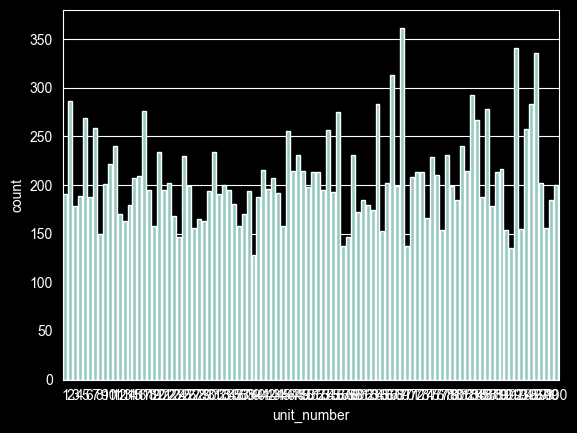

In [115]:
failure_cycles=group_df["time_in_cycles"]["count"]#Failure cycles of the machines
sns.barplot(failure_cycles)
plt.show()

In [116]:
failure_cycles.min()# this train data has minimum 128 cycles after broken machines.
failure_cycles.median()#This means that machines generally fail around 199 cycles.
failure_cycles.max()#This machines more durable than other machines

np.float64(362.0)

# Okay, let's continue with 3 machines to understand the data better.
* Machine 1 -> Machine to first failure, the has minimum cycle (128 cycle)
* Machine 2 -> This machine has an median cycle.(199 cycle)
* Machine 3 -> This machine, that actually we don't know its conditions, much quality machine from the dataset.(362 cycle)